In [1]:
import pandas as pd
import json

In [2]:
filename = 'data/20260105_8278074507_MiFitness_hlth_center_aggregated_fitness_data.csv'
df = pd.read_csv(filename)

In [3]:
print(list(df.columns))

['Uid', 'Sid', 'Tag', 'Key', 'Time', 'Value', 'UpdateTime']


In [4]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

Access one specific(epoch = 1767484800) `sleep` data

In [5]:
sleep_data_1767484800 = df.Value[(df.Key == 'sleep') & (df.Time == 1767484800) & (df.Tag == 'daily_report')]
sleep_data_1767484800

1038    {"total_turn_over":0,"sleep_deep_duration":114,"avg_spo2":98,"day_sleep_evaluation":0,"avg_hr":49,"total_snore_disturb":0,"total_duration":441,"awake_count":2,"total_body_move":0,"sleep_rem_duration":102,"breath_quality":0,"sleep_awake_duration":6,"max_spo2":99,"total_snore":0,"sleep_light_duration":225,"sleep_nap_duration":0,"segment_details":[{"avg_hr":49,"bedtime":1767482880,"max_spo2":99,"min_hr":41,"sleep_rem_duration":102,"timezone":4,"sleep_light_duration":225,"sleep_deep_duration":114,"sleep_awake_duration":6,"duration":441,"max_hr":80,"awake_count":2,"avg_spo2":98,"min_spo2":95,"wake_up_time":1767509700}],"max_hr":80,"min_spo2":95,"sleep_trace_duration":0,"min_hr":41,"long_sleep_evaluation":3,"sleep_algorithm_version":0,"sleep_score":80,"total_long_duration":441,"sleep_manually_duration":0}
Name: Value, dtype: str

Parse JSON of one specific(epoch = 1767484800) `sleep` data into a new DF

In [6]:

sleep_data_1767484800_json = json.loads('[' + ','.join(sleep_data_1767484800) + ']')
sleep_data_1767484800_df = pd.json_normalize(data=sleep_data_1767484800_json, max_level=2)
sleep_data_1767484800_df


,total_turn_over,sleep_deep_duration,avg_spo2,day_sleep_evaluation,avg_hr,total_snore_disturb,total_duration,awake_count,total_body_move,sleep_rem_duration,breath_quality,sleep_awake_duration,max_spo2,total_snore,sleep_light_duration,sleep_nap_duration,segment_details,max_hr,min_spo2,sleep_trace_duration,min_hr,long_sleep_evaluation,sleep_algorithm_version,sleep_score,total_long_duration,sleep_manually_duration
0,0,114,98,0,49,0,441,2,0,102,0,6,99,0,225,0,"[{'avg_hr': 49, 'bedtime': 1767482880, 'max_spo2': 99, 'min_hr': 41, 'sleep_rem_duration': 102, 'timezone': 4, 'sleep_light_duration': 225, 'sleep_deep_duration': 114, 'sleep_awake_duration': 6, 'duration': 441, 'max_hr': 80, 'awake_count': 2, 'avg_spo2': 98, 'min_spo2': 95, 'wake_up_time': 1767509700}]",80,95,0,41,3,0,80,441,0


1. Access `segment_details` data
2. Turn into a new df
3. Merge two df

In [7]:
# 1 - access
sleep_data_1767484800_df['segment_details']

# 2 - new df
sleep_data_1767484800_segment_details_df = pd.json_normalize(sleep_data_1767484800_df.explode('segment_details')['segment_details'])

# 3 - merge
sleep_data_1767484800_merged_df = pd.merge(sleep_data_1767484800_df.drop(columns=['segment_details']), sleep_data_1767484800_segment_details_df, how = 'inner')
sleep_data_1767484800_merged_df

,total_turn_over,sleep_deep_duration,avg_spo2,day_sleep_evaluation,avg_hr,total_snore_disturb,total_duration,awake_count,total_body_move,sleep_rem_duration,breath_quality,sleep_awake_duration,max_spo2,total_snore,sleep_light_duration,sleep_nap_duration,max_hr,min_spo2,sleep_trace_duration,min_hr,long_sleep_evaluation,sleep_algorithm_version,sleep_score,total_long_duration,sleep_manually_duration,bedtime,timezone,duration,wake_up_time
0,0,114,98,0,49,0,441,2,0,102,0,6,99,0,225,0,80,95,0,41,3,0,80,441,0,1767482880,4,441,1767509700


Drop duplicates
- `duration`
- `total_duration`
- `total_long_duration`

**TODO**
Why those duplicates exist?

Drop unimportant values
- breath_quality
- sleep_algorithm_version
- sleep_trace_duration
- total_body_move
- total_snore
- total_snore_disturb
- total_turn_over
- total_duration
- total_long_duration

In [8]:
sleep_data_1767484800_merged_dropped_df = sleep_data_1767484800_merged_df.drop(columns=['breath_quality', 'sleep_algorithm_version', 'sleep_trace_duration', 'total_body_move',  'total_snore', 'total_snore_disturb', 'total_turn_over', 'total_duration', 'total_long_duration'])
sleep_data_1767484800_merged_dropped_df

,sleep_deep_duration,avg_spo2,day_sleep_evaluation,avg_hr,awake_count,sleep_rem_duration,sleep_awake_duration,max_spo2,sleep_light_duration,sleep_nap_duration,max_hr,min_spo2,min_hr,long_sleep_evaluation,sleep_score,sleep_manually_duration,bedtime,timezone,duration,wake_up_time
0,114,98,0,49,2,102,6,99,225,0,80,95,41,3,80,0,1767482880,4,441,1767509700


1. Sort columns alphabetically
2. Arrange columns in a sensible way - is it needed? / is it a practice?
   1. Time
      1. bedtime
      2. wake_up_time
      3. timezone
   2. Duration
      1. duration
      2. sleep_awake_duration
      3. sleep_deep_duration
      4. sleep_light_duration
      5. sleep_manually_duration
      6. sleep_nap_duration
      7. sleep_rem_duration
   3. HR
      1. avg_hr
      2. max_hr
      3. min_hr
   4. SpO2
      1. avg_spo2
      2. max_spo2
      3. min_spo2

In [9]:
sleep_data_1767484800_merged_dropped_sorted_df = sleep_data_1767484800_merged_dropped_df.sort_index(axis = 1)
sleep_data_1767484800_merged_dropped_sorted_df 

,avg_hr,avg_spo2,awake_count,bedtime,day_sleep_evaluation,duration,long_sleep_evaluation,max_hr,max_spo2,min_hr,min_spo2,sleep_awake_duration,sleep_deep_duration,sleep_light_duration,sleep_manually_duration,sleep_nap_duration,sleep_rem_duration,sleep_score,timezone,wake_up_time
0,49,98,2,1767482880,0,441,3,80,99,41,95,6,114,225,0,0,102,80,4,1767509700


**TODO**
1. Add Uid, Key and Time for one row
2. Merge dfs
3. Change epoch to dates

In [10]:
# Add Uid, Key and Time for one row
sleep_data_1767484800_uid_key_time = df[(df.Key == 'sleep') & (df.Time == 1767484800) & (df.Tag == 'daily_report')].drop(columns=['Value', 'Sid', 'Tag', 'UpdateTime'])

all_sleep_data_1767484800_uid_key_time = sleep_data_1767484800_uid_key_time.merge(sleep_data_1767484800_merged_dropped_sorted_df, how='outer', left_index=True, right_index=True)
all_sleep_data_1767484800_uid_key_time

# Change epoch to dates


,Uid,Key,Time,avg_hr,avg_spo2,awake_count,bedtime,day_sleep_evaluation,duration,long_sleep_evaluation,max_hr,max_spo2,min_hr,min_spo2,sleep_awake_duration,sleep_deep_duration,sleep_light_duration,sleep_manually_duration,sleep_nap_duration,sleep_rem_duration,sleep_score,timezone,wake_up_time
0,NaN,NaN,NaN,49.0,98.0,2.0,1.767483e+09,0.0,441.0,3.0,80.0,99.0,41.0,95.0,6.0,114.0,225.0,0.0,0.0,102.0,80.0,4.0,1.767510e+09
1038,8.278075e+09,sleep,1.767485e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**TODO**
1. Data cleaning for every row
2. Parse JSONs of `sleep` into a new DF
`Uid`, `Key`, `Time`, `avg_spo2` ...

In [11]:
all_sleep_data = df.Value[(df.Key == 'sleep') & (df.Tag == 'daily_report')]
all_sleep_data_json = json.loads('[' + ','.join(all_sleep_data) + ']')
all_sleep_data_df = pd.json_normalize(data=all_sleep_data_json, max_level=2)
all_sleep_data_df

,total_duration,sleep_rem_duration,sleep_nap_duration,total_turn_over,avg_hr,avg_spo2,sleep_light_duration,total_long_duration,sleep_score,day_sleep_evaluation,sleep_trace_duration,sleep_manually_duration,sleep_awake_duration,total_snore,breath_quality,long_sleep_evaluation,total_body_move,awake_count,max_hr,total_snore_disturb,segment_details,sleep_deep_duration,min_hr,min_spo2,max_spo2,sleep_algorithm_version
0,428,125,0,0,56,0,167,428,70,0,0,0,34,0,0,20,0,2,80,0,"[{'awake_count': 2, 'wake_up_time': 1736930100, 'duration': 428, 'sleep_deep_duration': 136, 'timezone': 4, 'bedtime': 1736902380, 'min_hr': 48, 'max_hr': 80, 'sleep_awake_duration': 34, 'sleep_rem_duration': 125, 'avg_hr': 56, 'sleep_light_duration': 167}]",136,48,NaN,NaN,NaN
1,515,119,65,0,54,0,226,450,77,0,0,0,14,0,0,17,0,1,79,0,"[{'awake_count': 1, 'sleep_light_duration': 226, 'sleep_rem_duration': 119, 'bedtime': 1736985060, 'sleep_deep_duration': 105, 'wake_up_time': 1737012900, 'sleep_awake_duration': 14, 'max_hr': 65, 'min_hr': 43, 'duration': 450, 'timezone': 4, 'avg_hr': 50}, {'sleep_light_duration': 0, 'bedtime': 1737018240, 'max_hr': 79, 'awake_count': 0, 'wake_up_time': 1737022140, 'sleep_rem_duration': 0, 'avg_hr': 58, 'min_hr': 53, 'sleep_deep_duration': 0, 'duration': 65, 'sleep_awake_duration': 0, 'timezone': 4}]",105,43,NaN,NaN,NaN
2,496,121,0,0,57,0,247,496,86,0,0,0,17,0,0,6,0,2,99,0,"[{'sleep_rem_duration': 121, 'wake_up_time': 1737100800, 'duration': 496, 'bedtime': 1737070020, 'max_hr': 99, 'sleep_deep_duration': 128, 'avg_hr': 57, 'sleep_light_duration': 247, 'min_hr': 47, 'sleep_awake_duration': 17, 'timezone': 4, 'awake_count': 2}]",128,47,NaN,NaN,NaN
3,523,121,0,0,50,0,246,523,93,0,0,0,0,0,0,26,0,0,79,0,"[{'duration': 523, 'sleep_light_duration': 246, 'sleep_deep_duration': 156, 'sleep_rem_duration': 121, 'min_hr': 43, 'timezone': 4, 'avg_hr': 50, 'bedtime': 1737154020, 'wake_up_time': 1737185400, 'sleep_awake_duration': 0, 'awake_count': 0, 'max_hr': 79}]",156,43,NaN,NaN,NaN
4,432,108,0,0,50,0,172,432,83,0,0,0,4,0,0,26,0,1,61,0,"[{'timezone': 4, 'sleep_awake_duration': 4, 'awake_count': 1, 'wake_up_time': 1737271800, 'max_hr': 61, 'duration': 432, 'min_hr': 40, 'sleep_deep_duration': 152, 'sleep_rem_duration': 108, 'avg_hr': 50, 'bedtime': 1737245640, 'sleep_light_duration': 172}]",152,40,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,1087,155,469,0,59,97,259,805,78,1,0,0,12,0,0,18,0,3,96,0,"[{'max_hr': 96, 'avg_hr': 53, 'min_spo2': 94, 'bedtime': 1767130560, 'sleep_light_duration': 259, 'sleep_deep_duration': 204, 'min_hr': 46, 'sleep_rem_duration': 155, 'sleep_awake_duration': 12, 'awake_count': 3, 'max_spo2': 99, 'avg_spo2': 97, 'wake_up_time': 1767168360, 'timezone': 4, 'duration': 618}, {'max_hr': 67, 'avg_hr': 61, 'min_spo2': 95, 'bedtime': 1767174060, 'sleep_light_duration': 0, 'sleep_deep_duration': 0, 'min_hr': 57, 'sleep_rem_duration': 0, 'sleep_awake_duration': 0, 'awake_count': 0, 'max_spo2': 95, 'avg_spo2': 95, 'wake_up_time': 1767177060, 'timezone': 4, 'duration': 187}, {'max_hr': 85, 'avg_hr': 62, 'min_spo2': 95, 'bedtime': 1767178260, 'sleep_light_duration': 0, 'sleep_deep_duration': 0, 'min_hr': 56, 'sleep_rem_duration': 0, 'sleep_awake_duration': 0, 'awake_count': 0, 'max_spo2': 99, 'avg_spo2': 97, 'wake_up_time': 1767186480, 'timezone': 4, 'duration': 137}, {'max_hr': 78, 'avg_hr': 61, 'min_spo2': 94, 'bedtime': 1767195780, 'sleep_light_duration': 0, 'sleep_deep_duration': 0, 'min_hr': 56, 'sleep_rem_duration': 0, 'sleep_awake_duration': 0, 'awake_count': 0, 'max_spo2': 99, 'avg_spo2': 97, 'wake_up_time': 1767204480, 'timezone': 4, 'duration': 145}]",204,46,94.0,99.0,0.0
159,572,97,62,0,55,97,236,510,80,0,0,0,9,0,0,17,0,1,81,0,"[{'sleep_rem_duration': 97, 'duration': 510, 'max_spo2': 99, 'bedtime': 1767225060, 'max_hr': 81, 'avg_hr': 51, 'awake_count': 1, 'min_spo2': 94, 'avg_spo2': 97, 'sleep_deep_duration': 177, 'wake_up_time': 1767256200, 'm

In [12]:
#df.Value[(df.Time == 1767484800)]

Graphs

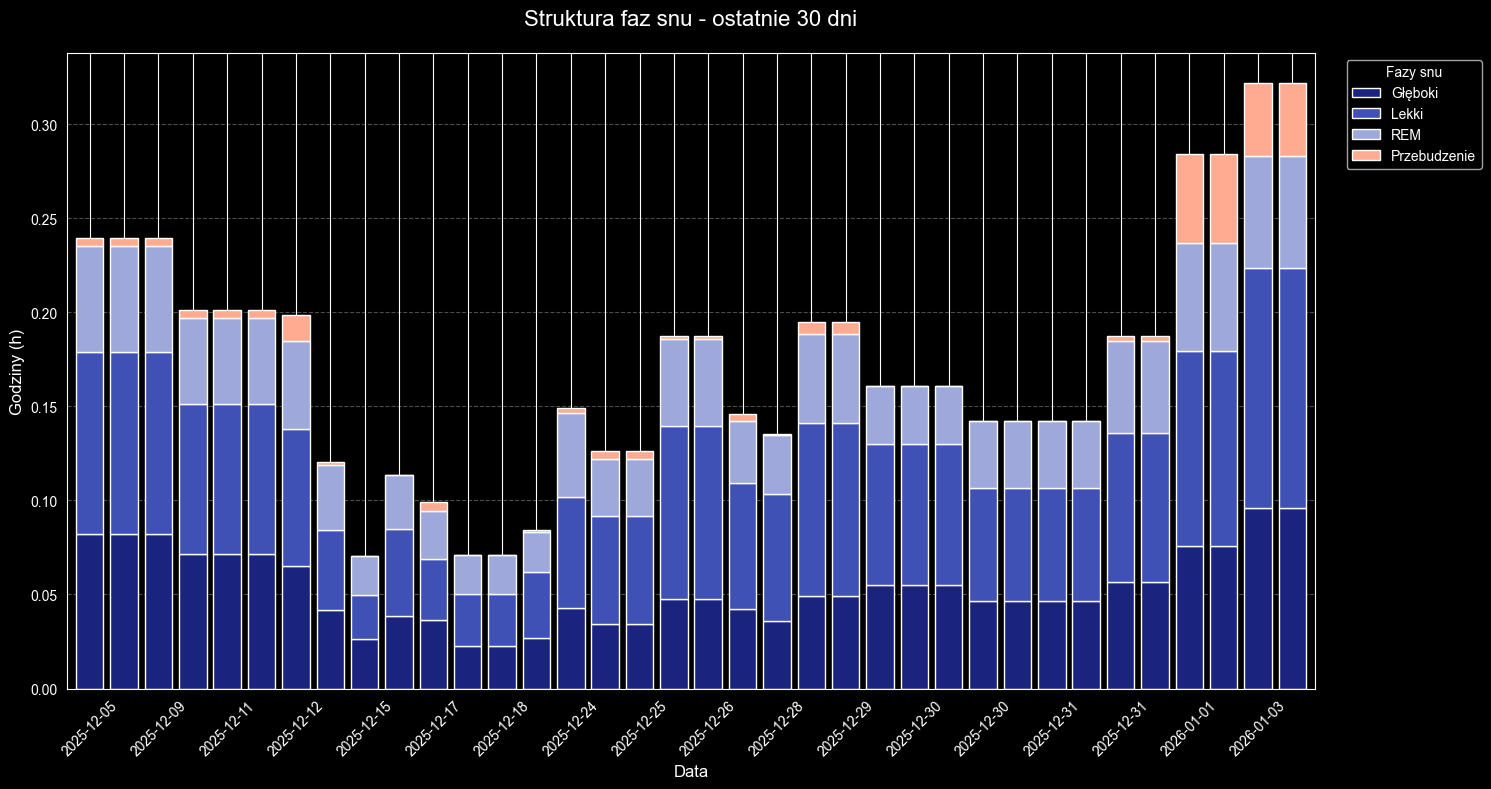

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. NAPRAWA TYPÓW DANYCH (Kluczowe dla błędu TypeError) ---
duration_cols = ['sleep_deep_duration', 'sleep_light_duration', 'sleep_rem_duration', 'sleep_awake_duration']

for col in duration_cols:
    if col in all_sleep_data_df.columns:
        # Konwersja na liczby, błędy zamieniamy na NaN
        all_sleep_data_df[col] = pd.to_numeric(all_sleep_data_df[col], errors='coerce')
        # Obliczamy godziny i wypełniamy braki (NaN) zerami
        all_sleep_data_df[f'{col}_h'] = (all_sleep_data_df[col].fillna(0) / 3600).astype(float)

# --- 2. FILTROWANIE (Ostatnie 30 dni) ---
# Upewniamy się, że mamy daty sformatowane do wyświetlania
if 'date_dt' in all_sleep_data_df.columns:
    start_date = all_sleep_data_df['date_dt'].max() - pd.Timedelta(days=30)
    df_plot = all_sleep_data_df[all_sleep_data_df['date_dt'] >= start_date].copy()
    df_plot['date_str'] = df_plot['date_dt'].dt.strftime('%Y-%m-%d')
else:
    # Jeśli nie ma date_dt, bierzemy ostatnie 30 rekordów
    df_plot = all_sleep_data_df.tail(30).copy()
    df_plot['date_str'] = range(len(df_plot))

# --- 3. PRZYGOTOWANIE KOLUMN DO WYKRESU ---
plot_cols_map = {
    'sleep_deep_duration_h': 'Głęboki',
    'sleep_light_duration_h': 'Lekki',
    'sleep_rem_duration_h': 'REM',
    'sleep_awake_duration_h': 'Przebudzenie'
}
# Wybieramy tylko te kolumny, które faktycznie istnieją i są numeryczne
available_cols = [c for c in plot_cols_map.keys() if c in df_plot.columns]

# --- 4. RYSOWANIE WYKRESU ---
if len(available_cols) > 0:
    plt.figure(figsize=(15, 8))

    # Tworzymy wykres słupkowy skumulowany
    ax = df_plot.set_index('date_str')[available_cols].plot(
        kind='bar',
        stacked=True,
        ax=plt.gca(),
        color=['#1a237e', '#3f51b5', '#9fa8da', '#ffab91'],
        width=0.8
    )

    # Tytuł i etykiety
    plt.title(f'Struktura faz snu - ostatnie 30 dni', fontsize=16, pad=20)
    plt.ylabel('Godziny (h)', fontsize=12)
    plt.xlabel('Data', fontsize=12)

    # Legenda z ładnymi nazwami
    plt.legend([plot_cols_map[c] for c in available_cols],
               title="Fazy snu", bbox_to_anchor=(1.02, 1), loc='upper left')

    # Poprawa czytelności osi X (pokazuj co drugą datę)
    n = 2
    for i, label in enumerate(ax.xaxis.get_ticklabels()):
        if i % n != 0:
            label.set_visible(False)

    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Błąd: Nie znaleziono danych numerycznych o czasie trwania snu.")

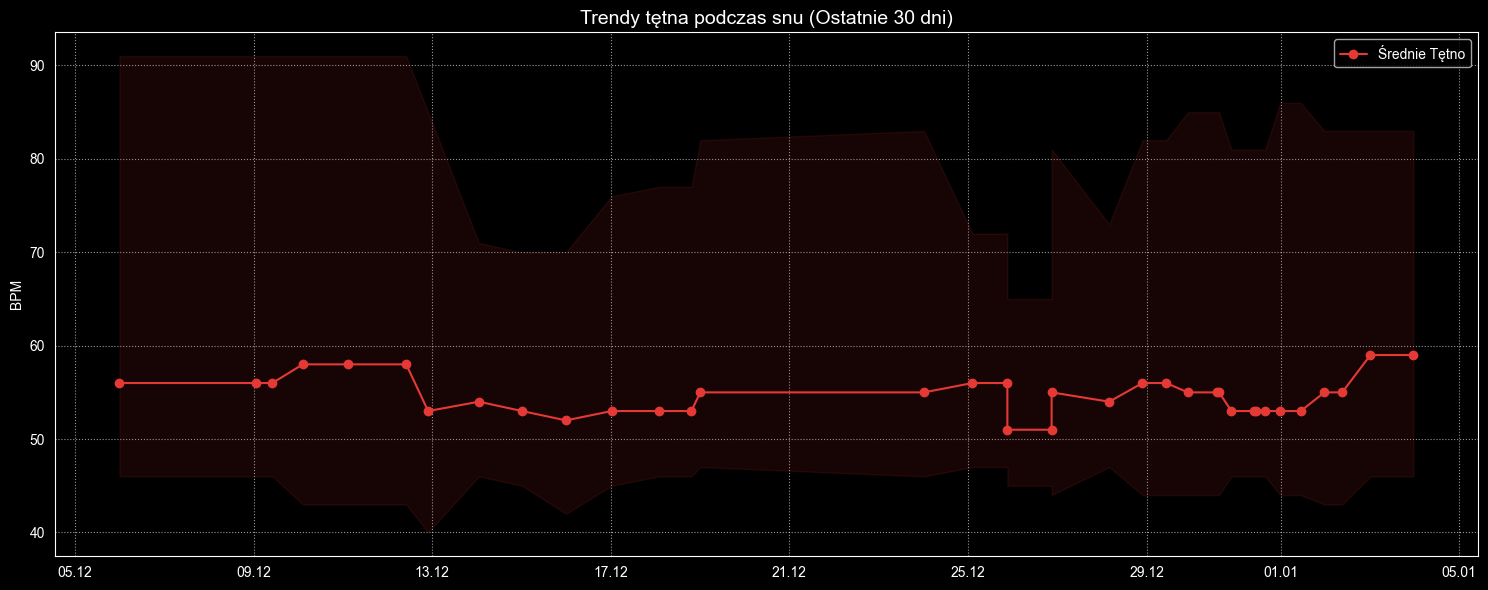

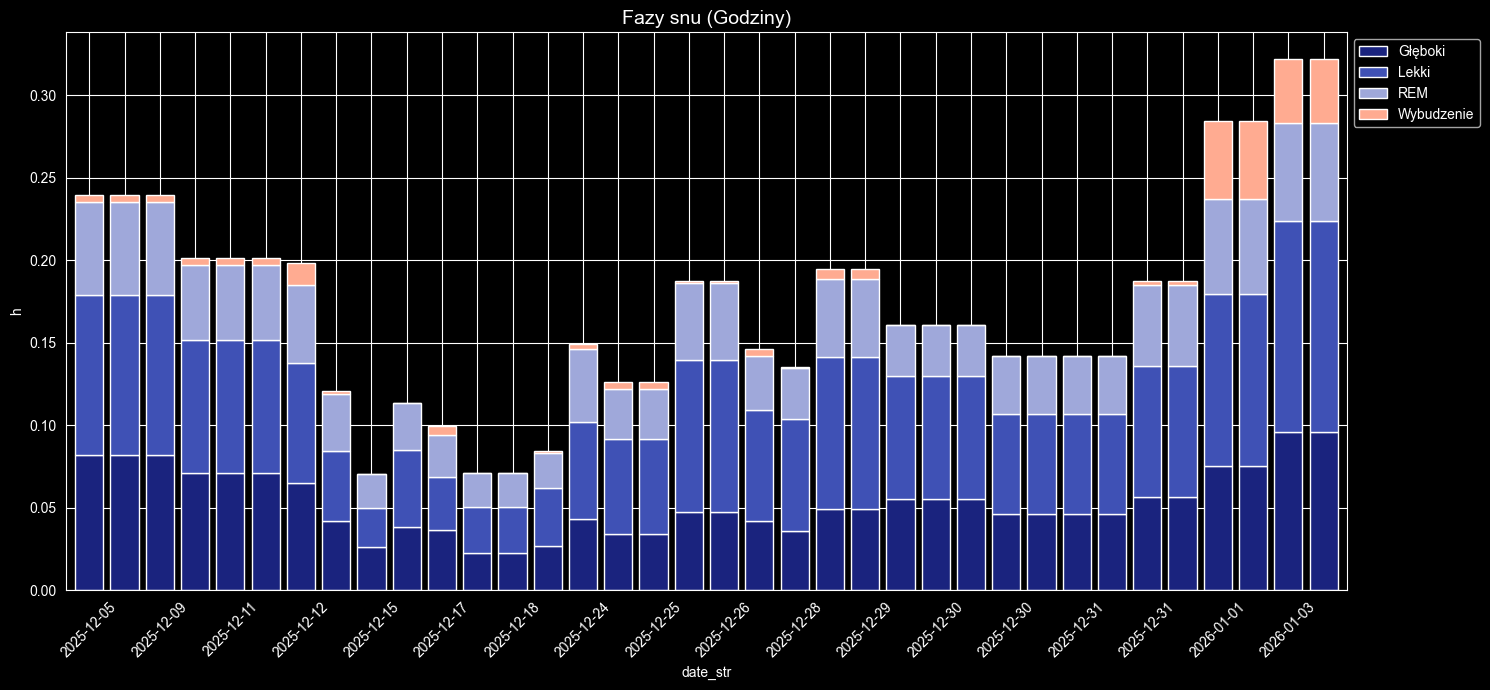

In [31]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- KROK 1: PARSOWANIE I PRZYGOTOWANIE DANYCH ---
# (Uruchom to, jeśli jeszcze nie masz przetworzonego all_sleep_data_df)
raw_sleep_values = df.Value[(df.Key == 'sleep') & (df.Tag == 'daily_report')]
all_sleep_data_json = json.loads('[' + ','.join(raw_sleep_values) + ']')
temp_df = pd.json_normalize(data=all_sleep_data_json, max_level=2)

# Rozpakowanie segment_details (tu jest 'bedtime')
if 'segment_details' in temp_df.columns:
    df_exploded = temp_df.explode('segment_details')
    segments_df = pd.json_normalize(df_exploded['segment_details'])
    all_sleep_data_df = df_exploded.drop(columns=['segment_details']).reset_index(drop=True).join(segments_df, rsuffix='_seg')
else:
    all_sleep_data_df = temp_df

# Tworzenie kolumny daty (date_dt) i sortowanie
time_col = 'bedtime' if 'bedtime' in all_sleep_data_df.columns else 'bedtime_seg'
all_sleep_data_df['date_dt'] = pd.to_datetime(all_sleep_data_df[time_col], unit='s')
all_sleep_data_df = all_sleep_data_df.dropna(subset=['date_dt']).sort_values('date_dt')

# Konwersja tętna i faz snu na liczby (naprawa błędu TypeError)
numeric_cols = ['avg_hr', 'min_hr', 'max_hr', 'sleep_deep_duration', 'sleep_light_duration', 'sleep_rem_duration', 'sleep_awake_duration']
for col in numeric_cols:
    if col in all_sleep_data_df.columns:
        all_sleep_data_df[col] = pd.to_numeric(all_sleep_data_df[col], errors='coerce').fillna(0)
        if 'duration' in col:
            all_sleep_data_df[f'{col}_h'] = all_sleep_data_df[col] / 3600

# --- KROK 2: FILTROWANIE (Ostatnie 30 dni dla czytelności) ---
start_date = all_sleep_data_df['date_dt'].max() - pd.Timedelta(days=30)
df_filtered = all_sleep_data_df[all_sleep_data_df['date_dt'] >= start_date].copy()
df_filtered['date_str'] = df_filtered['date_dt'].dt.strftime('%Y-%m-%d')

# --- WYKRES 1: TREND TĘTNA (Line Plot) ---
plt.figure(figsize=(15, 6))
plt.plot(df_filtered['date_dt'], df_filtered['avg_hr'], color='#e53935', marker='o', label='Średnie Tętno')
plt.fill_between(df_filtered['date_dt'], df_filtered['min_hr'], df_filtered['max_hr'], color='#e53935', alpha=0.1)

plt.title('Trendy tętna podczas snu (Ostatnie 30 dni)', fontsize=14)
plt.ylabel('BPM')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# --- WYKRES 2: STRUKTURA FAZ SNU (Stacked Bar) ---
plt.figure(figsize=(15, 7))
plot_cols_map = {
    'sleep_deep_duration_h': 'Głęboki',
    'sleep_light_duration_h': 'Lekki',
    'sleep_rem_duration_h': 'REM',
    'sleep_awake_duration_h': 'Wybudzenie'
}
available_cols = [c for c in plot_cols_map.keys() if c in df_filtered.columns]

ax = df_filtered.set_index('date_str')[available_cols].plot(
    kind='bar', stacked=True, ax=plt.gca(),
    color=['#1a237e', '#3f51b5', '#9fa8da', '#ffab91'], width=0.8
)

plt.title('Fazy snu (Godziny)', fontsize=14)
plt.ylabel('h')
plt.legend([plot_cols_map[c] for c in available_cols], bbox_to_anchor=(1.0, 1.0))

# Ukrywanie co drugiej etykiety, aby os X była czytelna
for i, label in enumerate(ax.xaxis.get_ticklabels()):
    if i % 2 != 0: label.set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Twoje dane zaczynają się: 2025-01-15 00:53:00
Twoje dane kończą się:   2026-01-03 23:28:00

UWAGA: Brak danych dla 3/2026. Automatycznie wybieram ostatni miesiąc w pliku...
Wyświetlam dane dla: 01.2026


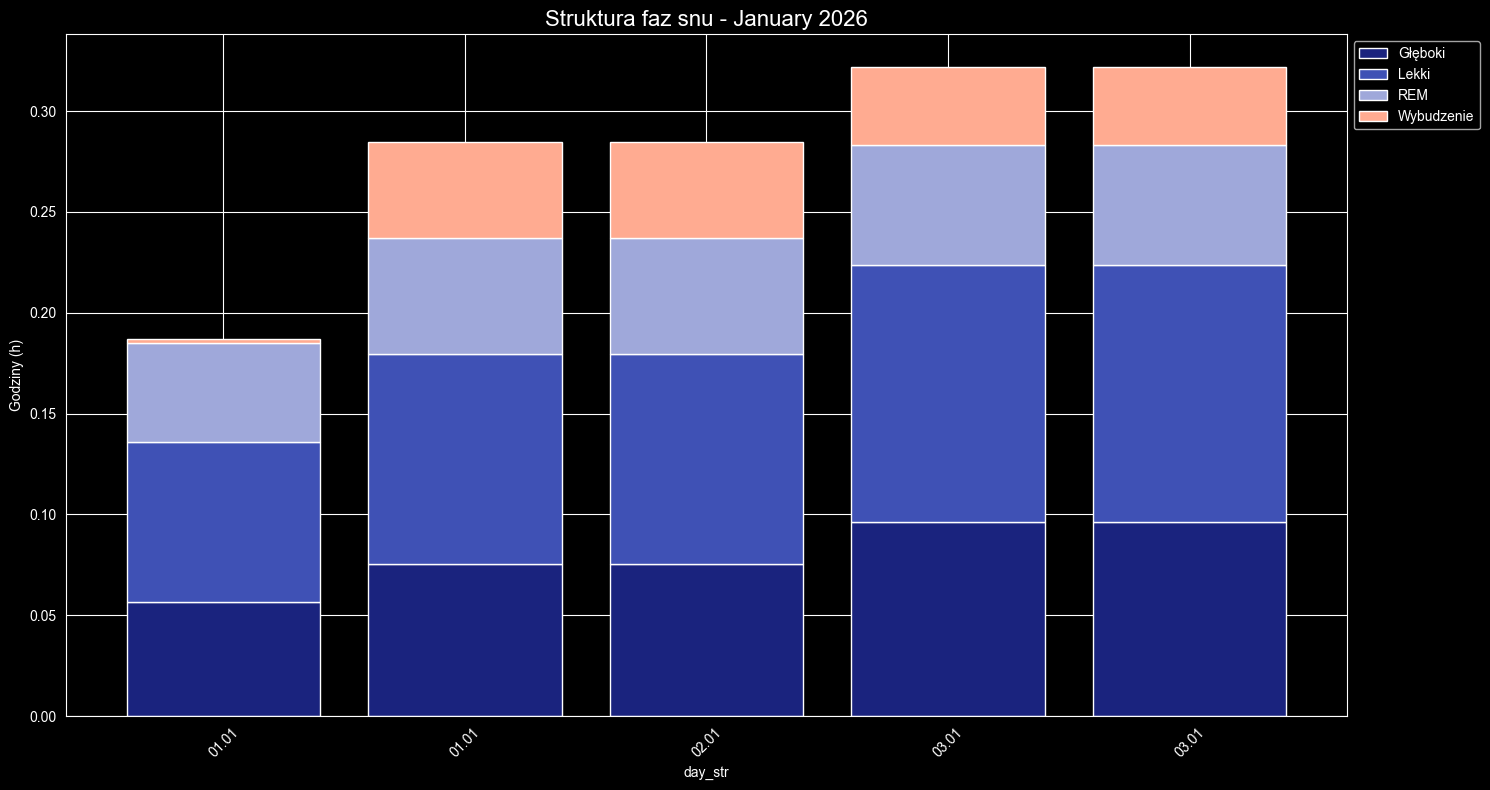

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# --- KROK 1: DIAGNOSTYKA DAT ---
min_date = all_sleep_data_df['date_dt'].min()
max_date = all_sleep_data_df['date_dt'].max()

print(f"Twoje dane zaczynają się: {min_date}")
print(f"Twoje dane kończą się:   {max_date}")

# --- KROK 2: AUTOMATYCZNE FILTROWANIE ---
# Jeśli marzec 2026 jest pusty, spróbujmy przefiltrować na marzec 2025
# lub po prostu ostatni miesiąc jaki jest w danych.

target_month = 3
target_year = 2026

df_filtered = all_sleep_data_df[
    (all_sleep_data_df['date_dt'].dt.year == target_year) &
    (all_sleep_data_df['date_dt'].dt.month == target_month)
].copy()

# JEŚLI MARZEC 2026 JEST PUSTY -> BIERZEMY OSTATNI DOSTĘPNY MIESIĄC
if df_filtered.empty:
    print(f"\nUWAGA: Brak danych dla {target_month}/{target_year}. Automatycznie wybieram ostatni miesiąc w pliku...")
    last_date = all_sleep_data_df['date_dt'].max()
    df_filtered = all_sleep_data_df[
        (all_sleep_data_df['date_dt'].dt.year == last_date.year) &
        (all_sleep_data_df['date_dt'].dt.month == last_date.month)
    ].copy()
    print(f"Wyświetlam dane dla: {last_date.strftime('%m.%Y')}")

# --- KROK 3: RYSOWANIE WYKRESU ---
df_filtered = df_filtered.sort_values('date_dt')
df_filtered['day_str'] = df_filtered['date_dt'].dt.strftime('%d.%m')

plot_cols_map = {
    'sleep_deep_duration_h': 'Głęboki',
    'sleep_light_duration_h': 'Lekki',
    'sleep_rem_duration_h': 'REM',
    'sleep_awake_duration_h': 'Wybudzenie'
}
available_cols = [c for c in plot_cols_map.keys() if c in df_filtered.columns]

if not df_filtered.empty:
    plt.figure(figsize=(15, 8))
    ax = df_filtered.set_index('day_str')[available_cols].plot(
        kind='bar', stacked=True, ax=plt.gca(),
        color=['#1a237e', '#3f51b5', '#9fa8da', '#ffab91'], width=0.8
    )

    plt.title(f'Struktura faz snu - {df_filtered["date_dt"].iloc[0].strftime("%B %Y")}', fontsize=16)
    plt.ylabel('Godziny (h)')
    plt.legend([plot_cols_map[c] for c in available_cols], bbox_to_anchor=(1.0, 1.0))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

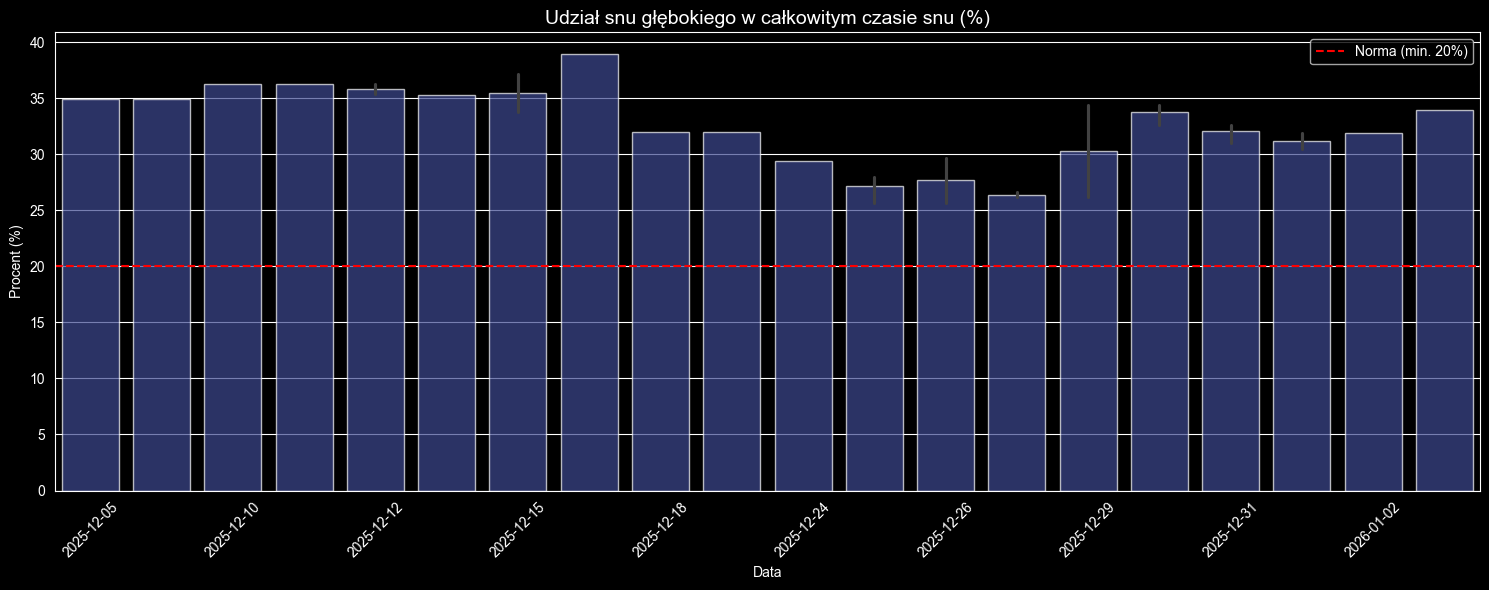

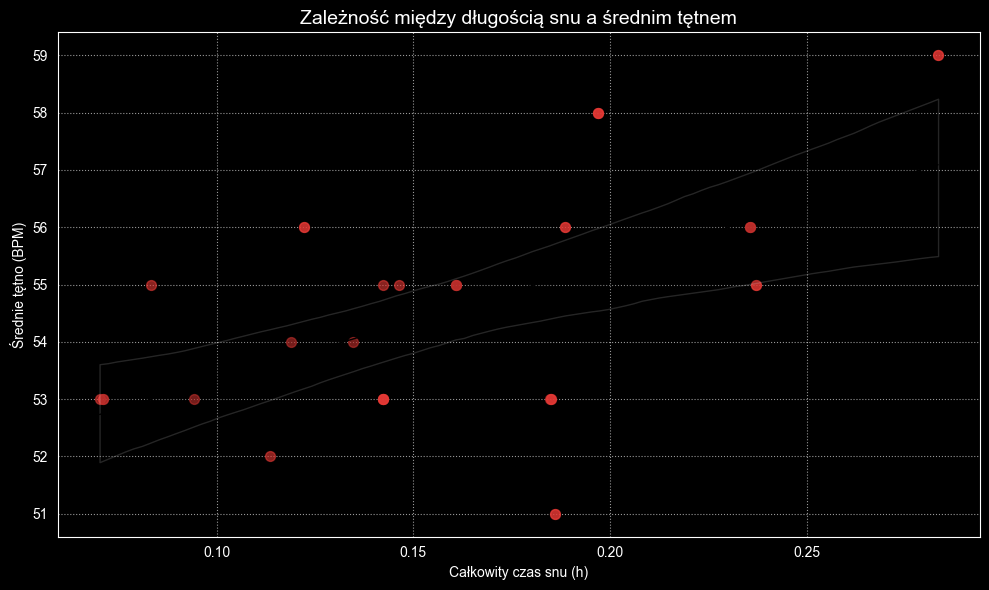

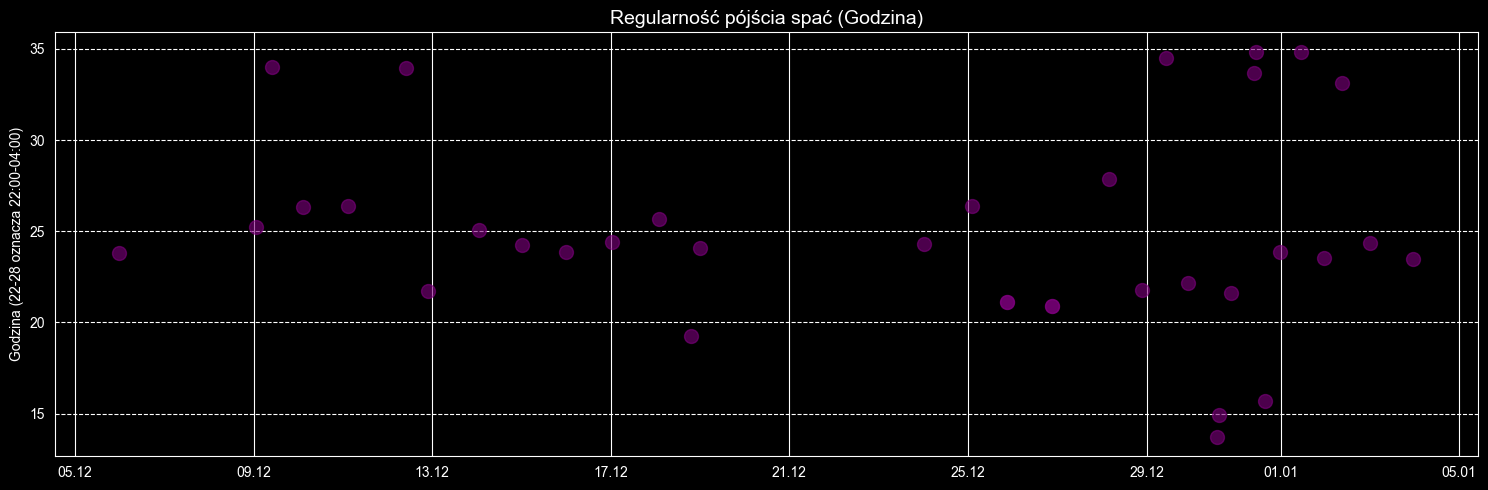

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Zakładamy, że df_filtered z poprzedniego kroku jest dostępny.
# Jeśli nie, upewnij się, że masz przeliczone kolumny _h (godziny).

# --- OBLICZENIA DODATKOWE ---
# 1. Całkowity czas snu
df_filtered['total_sleep_h'] = (
    df_filtered['sleep_deep_duration_h'] +
    df_filtered['sleep_light_duration_h'] +
    df_filtered['sleep_rem_duration_h']
)

# 2. Procent snu głębokiego (wskaźnik jakości)
df_filtered['deep_sleep_pct'] = (df_filtered['sleep_deep_duration_h'] / df_filtered['total_sleep_h']) * 100

# --- WYKRES 3: JAKOŚĆ SNU (% Snu Głębokiego) ---
plt.figure(figsize=(15, 6))
sns.barplot(x='date_str', y='deep_sleep_pct', data=df_filtered, color='#303f9f', alpha=0.7)
plt.axhline(y=20, color='red', linestyle='--', label='Norma (min. 20%)') # Linia referencyjna

plt.title('Udział snu głębokiego w całkowitym czasie snu (%)', fontsize=14)
plt.ylabel('Procent (%)')
plt.xlabel('Data')
plt.xticks(rotation=45)

# Ukrywanie co drugiej etykiety dla czytelności
ax = plt.gca()
for i, label in enumerate(ax.xaxis.get_ticklabels()):
    if i % 2 != 0: label.set_visible(False)

plt.legend()
plt.tight_layout()
plt.show()

# --- WYKRES 4: KORELACJA (Długość snu a tętno) ---
plt.figure(figsize=(10, 6))
sns.regplot(x='total_sleep_h', y='avg_hr', data=df_filtered,
            scatter_kws={'s': 50, 'alpha': 0.6, 'color': '#e53935'},
            line_kws={'color': 'black', 'lw': 1})

plt.title('Zależność między długością snu a średnim tętnem', fontsize=14)
plt.xlabel('Całkowity czas snu (h)')
plt.ylabel('Średnie tętno (BPM)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# --- WYKRES 5: ROZKŁAD GODZIN PÓJŚCIA SPAĆ ---
# Wyciągamy godzinę z bedtime (date_dt)
df_filtered['bedtime_hour'] = df_filtered['date_dt'].dt.hour + df_filtered['date_dt'].dt.minute/60
# Jeśli ktoś idzie spać po północy (np. 1:00), traktujemy to jako 25:00 dla lepszego wykresu
df_filtered['bedtime_hour_adj'] = df_filtered['bedtime_hour'].apply(lambda x: x if x > 12 else x + 24)

plt.figure(figsize=(15, 5))
plt.scatter(df_filtered['date_dt'], df_filtered['bedtime_hour_adj'], color='purple', s=100, alpha=0.6)

plt.title('Regularność pójścia spać (Godzina)', fontsize=14)
plt.ylabel('Godzina (22-28 oznacza 22:00-04:00)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.grid(True, axis='y', linestyle='--')
plt.tight_layout()
plt.show()

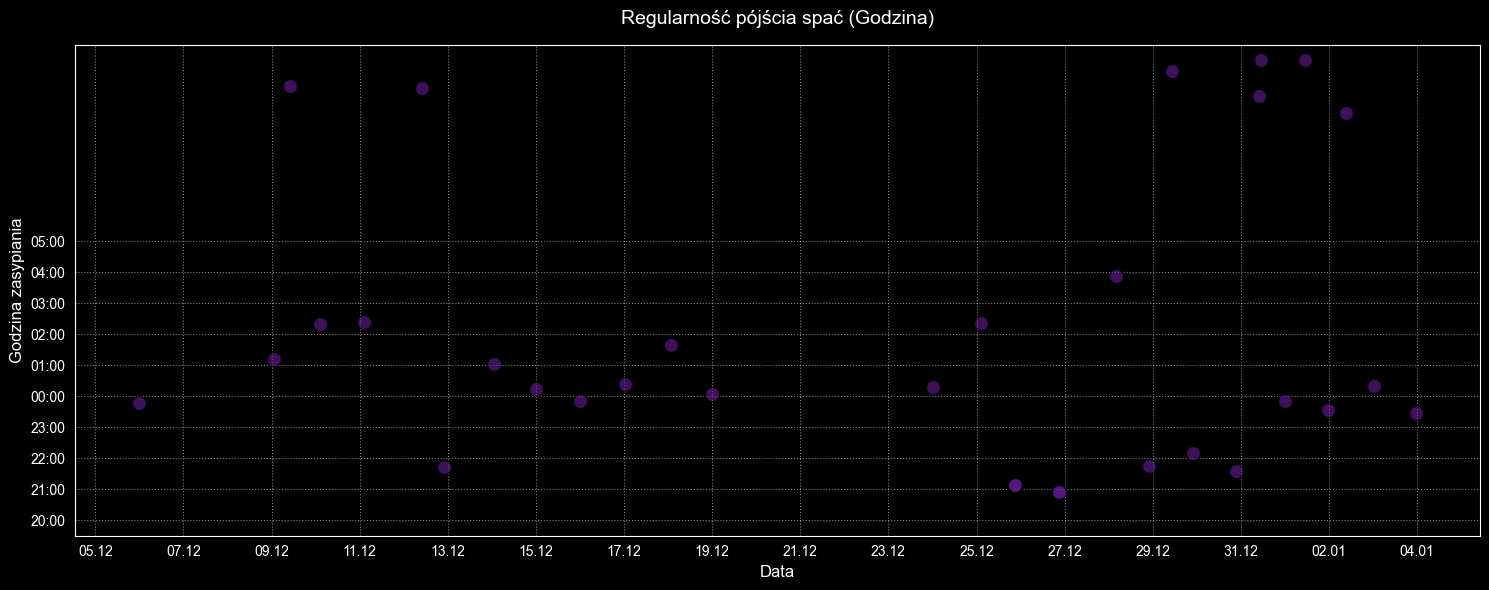

In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# --- WYKRES 5: ROZKŁAD GODZIN PÓJŚCIA SPAĆ (POPRAWIONY) ---

# 1. Obliczamy godzinę w formacie ułamkowym (np. 23.5 dla 23:30)
df_filtered['bedtime_hour'] = df_filtered['date_dt'].dt.hour + df_filtered['date_dt'].dt.minute/60

# 2. Przesuwamy godziny po północy (0-12) o 24h w górę, aby były nad 23:00 na wykresie
df_filtered['bedtime_hour_adj'] = df_filtered['bedtime_hour'].apply(lambda x: x if x > 12 else x + 24)

plt.figure(figsize=(15, 6))

# Rysujemy punkty
plt.scatter(df_filtered['date_dt'], df_filtered['bedtime_hour_adj'],
            color='#6a1b9a', s=100, alpha=0.6, edgecolors='black', label='Pora pójścia spać')

# --- KLUCZOWA POPRAWKA: FORMATAWANIE OSI Y ---
# Definiujemy zakres od 20:00 (wieczorem) do np. 05:00 rano (jako 29:00)
y_ticks = np.arange(20, 30, 1)
y_labels = [f"{int(h)%24:02d}:00" for h in y_ticks] # Zamiana 25:00 na 01:00 itd.

plt.yticks(y_ticks, y_labels)
plt.ylim(19.5, df_filtered['bedtime_hour_adj'].max() + 0.5) # Dynamiczny margines góra/dół

# --- FORMATOWANIE OSI X (DATY) ---
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2)) # Etykieta co 2 dni

plt.title('Regularność pójścia spać (Godzina)', fontsize=14, pad=15)
plt.ylabel('Godzina zasypiania', fontsize=12)
plt.xlabel('Data', fontsize=12)

plt.grid(True, axis='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()